# Training a Transformer for Machine Translation

---

In the previous notebooks, we learned:
- How neural networks work (gradients, backpropagation)
- How RNNs and Transformers process sequences
- The attention mechanism

**Now**: Let's put it all together and train a real translation model!

### What We'll Cover:
1. **Data Preparation**: Get, clean, tokenize, split data
2. **Model Architecture**: Build an encoder-decoder Transformer
3. **Training**: Loss functions and optimization
4. **Evaluation**: Metrics (BLEU, etc.) and why they differ from loss
5. **The Key Question**: Why use loss during training but BLEU for evaluation?

In [ ]:
# Make sure the packages are installed
!pip install numpy matplotlib graphviz torch

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import random
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn import Transformer
%matplotlib inline

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("✓ Libraries loaded!")
print(f"Using device: {device}")

✓ Libraries loaded!
Using device: cpu


## Part 1: Data Preparation

### The Translation Task

We'll build an English → Spanish translator. But the principles apply to any language pair!

**Example translations:**
- "Hello" → "Hola"
- "How are you?" → "¿Cómo estás?"
- "Good morning" → "Buenos días"

### Step 1: Get the Data

For this tutorial, we'll create a small dataset. In practice, you'd use:
- **Parallel corpora**: Pairs of sentences (source + translation)
- Examples: Europarl, UN corpus, OpenSubtitles, Tatoeba
- Millions of sentence pairs!

Our toy dataset will help us understand the full pipeline.


In [2]:
# Create a toy parallel corpus (English → Spanish)
# In practice, you'd load this from files

raw_data = [
    ("hello", "hola"),
    ("goodbye", "adiós"),
    ("thank you", "gracias"),
    ("please", "por favor"),
    ("good morning", "buenos días"),
    ("good night", "buenas noches"),
    ("how are you", "cómo estás"),
    ("I am fine", "estoy bien"),
    ("what is your name", "cómo te llamas"),
    ("my name is", "me llamo"),
    ("nice to meet you", "mucho gusto"),
    ("see you later", "hasta luego"),
    ("excuse me", "disculpe"),
    ("I love you", "te quiero"),
    ("happy birthday", "feliz cumpleaños"),
    ("congratulations", "felicidades"),
    ("good luck", "buena suerte"),
    ("welcome", "bienvenido"),
    ("yes", "sí"),
    ("no", "no"),
    ("maybe", "quizás"),
    ("I do not know", "no sé"),
    ("help me", "ayúdame"),
    ("I am hungry", "tengo hambre"),
    ("I am thirsty", "tengo sed"),
    ("where is", "dónde está"),
    ("how much", "cuánto cuesta"),
    ("very good", "muy bien"),
    ("not bad", "no mal"),
    ("so so", "así así"),
]

print(f"Dataset size: {len(raw_data)} parallel sentences")
print(f"\nFirst 5 examples:")
print("="*60)
for en, es in raw_data[:5]:
    print(f"  EN: {en:20} → ES: {es}")


Dataset size: 30 parallel sentences

First 5 examples:
  EN: hello                → ES: hola
  EN: goodbye              → ES: adiós
  EN: thank you            → ES: gracias
  EN: please               → ES: por favor
  EN: good morning         → ES: buenos días


### Step 2: Preprocessing

Before we can train, we need to:
1. **Normalize**: lowercase, remove extra spaces
2. **Add special tokens**:
   - `<SOS>` (Start Of Sentence): marks beginning
   - `<EOS>` (End Of Sentence): marks end
   - `<PAD>` (Padding): makes all sentences same length
   - `<UNK>` (Unknown): for words not in vocabulary

These tokens are crucial for seq2seq models!


In [3]:
# Define special tokens
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

def preprocess_sentence(sentence):
    """
    Preprocess a single sentence.
    
    STEP 1: Lowercase for consistency
    STEP 2: Strip extra whitespace
    STEP 3: Split into words (simple tokenization)
    """
    sentence = sentence.lower().strip()
    words = sentence.split()
    return words

def add_special_tokens(words):
    """
    Add SOS and EOS tokens to mark sentence boundaries.
    
    Why? The model needs to know where sentences start and end!
    """
    return [SOS_TOKEN] + words + [EOS_TOKEN]

# Preprocess all data
processed_data = []
for en, es in raw_data:
    en_words = add_special_tokens(preprocess_sentence(en))
    es_words = add_special_tokens(preprocess_sentence(es))
    processed_data.append((en_words, es_words))

print("Preprocessed Data Examples:")
print("="*60)
for i, (en, es) in enumerate(processed_data[:3]):
    print(f"\nExample {i+1}:")
    print(f"  EN: {' '.join(en)}")
    print(f"  ES: {' '.join(es)}")

print(f"\n💡 Notice the <SOS> and <EOS> tokens wrapping each sentence!")


Preprocessed Data Examples:

Example 1:
  EN: <SOS> hello <EOS>
  ES: <SOS> hola <EOS>

Example 2:
  EN: <SOS> goodbye <EOS>
  ES: <SOS> adiós <EOS>

Example 3:
  EN: <SOS> thank you <EOS>
  ES: <SOS> gracias <EOS>

💡 Notice the <SOS> and <EOS> tokens wrapping each sentence!


### Step 3: Building Vocabularies

We need to convert words → numbers (IDs) for the neural network.

**Process:**
1. Collect all unique words from the data
2. Assign each word a unique ID
3. Create lookup dictionaries: word ↔ ID

We need **separate vocabularies** for source (English) and target (Spanish)!


In [4]:
class Vocabulary:
    """
    Builds and manages a vocabulary for a language.
    
    Converts between words and IDs.
    """
    
    def __init__(self, name):
        self.name = name
        # Special tokens get IDs 0-3
        self.word2id = {
            PAD_TOKEN: 0,
            SOS_TOKEN: 1,
            EOS_TOKEN: 2,
            UNK_TOKEN: 3,
        }
        self.id2word = {v: k for k, v in self.word2id.items()}
        self.word_count = Counter()
    
    def add_sentence(self, words):
        """Add all words from a sentence to vocabulary."""
        for word in words:
            if word not in [SOS_TOKEN, EOS_TOKEN, PAD_TOKEN, UNK_TOKEN]:
                if word not in self.word2id:
                    # Assign new ID
                    idx = len(self.word2id)
                    self.word2id[word] = idx
                    self.id2word[idx] = word
                self.word_count[word] += 1
    
    def word_to_id(self, word):
        """Convert word to ID (use UNK if not in vocab)."""
        return self.word2id.get(word, self.word2id[UNK_TOKEN])
    
    def id_to_word(self, idx):
        """Convert ID to word."""
        return self.id2word.get(idx, UNK_TOKEN)
    
    def __len__(self):
        return len(self.word2id)


# Build vocabularies for English and Spanish
en_vocab = Vocabulary("English")
es_vocab = Vocabulary("Spanish")

print("Building vocabularies...")
for en_words, es_words in processed_data:
    en_vocab.add_sentence(en_words)
    es_vocab.add_sentence(es_words)

print(f"\n✓ English vocabulary size: {len(en_vocab)} words")
print(f"✓ Spanish vocabulary size: {len(es_vocab)} words")

print(f"\nMost common English words:")
for word, count in en_vocab.word_count.most_common(10):
    print(f"  {word}: {count} times")

print(f"\nExample word-to-ID mappings (English):")
for word in ["hello", "good", "you", "<SOS>", "<UNK>"]:
    word_id = en_vocab.word_to_id(word)
    print(f"  '{word}' → ID {word_id}")


Building vocabularies...

✓ English vocabulary size: 49 words
✓ Spanish vocabulary size: 48 words

Most common English words:
  you: 5 times
  i: 5 times
  good: 4 times
  am: 3 times
  is: 3 times
  how: 2 times
  name: 2 times
  me: 2 times
  not: 2 times
  so: 2 times

Example word-to-ID mappings (English):
  'hello' → ID 4
  'good' → ID 9
  'you' → ID 7
  '<SOS>' → ID 1
  '<UNK>' → ID 3


### Step 4: Train / Dev / Test Split

**Critical for proper evaluation!**

- **Train set** (70%): Used to train the model (update weights)
- **Dev set** (15%): Used during training to check progress and tune hyperparameters
- **Test set** (15%): Final evaluation ONLY (never seen during training!)

**Why split?**
- Prevents overfitting (memorizing training data)
- Ensures model generalizes to new, unseen data
- Test set gives unbiased performance estimate


In [5]:
# Shuffle data
random.shuffle(processed_data)

# Calculate split sizes
n_total = len(processed_data)
n_train = int(0.7 * n_total)
n_dev = int(0.15 * n_total)

# Split data
train_data = processed_data[:n_train]
dev_data = processed_data[n_train:n_train+n_dev]
test_data = processed_data[n_train+n_dev:]

print(f"Data Split:")
print("="*60)
print(f"  Train set: {len(train_data)} pairs ({len(train_data)/n_total*100:.1f}%)")
print(f"  Dev set:   {len(dev_data)} pairs ({len(dev_data)/n_total*100:.1f}%)")
print(f"  Test set:  {len(test_data)} pairs ({len(test_data)/n_total*100:.1f}%)")
print(f"  Total:     {n_total} pairs")

print(f"\n💡 We'll train on {len(train_data)} examples,")
print(f"   check progress on {len(dev_data)} examples,")
print(f"   and do final evaluation on {len(test_data)} examples.")


Data Split:
  Train set: 21 pairs (70.0%)
  Dev set:   4 pairs (13.3%)
  Test set:  5 pairs (16.7%)
  Total:     30 pairs

💡 We'll train on 21 examples,
   check progress on 4 examples,
   and do final evaluation on 5 examples.


## Part 2: Understanding Loss vs Evaluation Metrics

**The Key Question**: Why do we use different metrics for training vs evaluation?

### During Training: Cross-Entropy Loss

**What it is**: Measures how wrong our probability predictions are

**Formula**: For each word, compare predicted probabilities with the true word
```
Loss = -log(probability of correct word)
```

**Example**:
- True word: "hola" (ID=5)
- Model predicts: [0.1, 0.05, 0.6, 0.15, 0.1] (probabilities for each word)
- Loss = -log(0.6) ≈ 0.51
- Lower loss = better!

**Why use loss for training?**
✅ **Differentiable**: We can compute gradients!
✅ **Computed at every word**: Provides fine-grained feedback
✅ **Optimizable**: We can use gradient descent

### For Evaluation: BLEU Score

**What it is**: Compares generated translation with reference translation

**Measures**: N-gram overlap (how many 1-grams, 2-grams, 3-grams, 4-grams match?)

**Example**:
- Reference: "buenos días"  
- Prediction: "bueno día"
- BLEU considers: word overlap, word order, length

**Score**: 0 to 100 (higher = better match)

**Why NOT use BLEU for training?**
❌ **Not differentiable**: Can't compute gradients!
❌ **Discrete**: Small changes in prediction → same BLEU
❌ **Requires complete sentences**: Can't evaluate word-by-word
❌ **Computationally expensive**

### The Training Pipeline

```
TRAINING (uses loss):
1. Forward pass → generate probabilities for each word
2. Compute cross-entropy loss
3. Backpropagation → compute gradients
4. Update weights

EVALUATION (uses BLEU):
1. Generate complete translation
2. Compare with reference
3. Compute BLEU score
4. Use for checkpointing (save best model)
```

**Key insight**: Loss guides learning, BLEU measures quality!


## Part 3: Transformer Model Architecture

Now let's build a **real Transformer model** using PyTorch!

**Architecture Components**:
- **Embeddings**: Convert word IDs to dense vectors
- **Positional Encoding**: Add position information
- **Transformer**: Encoder-decoder with multi-head attention
- **Output Layer**: Predict next word probabilities

This is the same architecture used in production translation systems!


In [6]:
class PositionalEncoding(nn.Module):
    """
    Adds positional information to embeddings.
    
    Why? Transformers process all words in parallel, so we need to tell them
    about word order!
    """
    
    def __init__(self, d_model, max_len=100):
        super().__init__()
        
        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        # Use sine and cosine functions
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        """Add positional encoding to embeddings."""
        # x: (batch_size, seq_len, d_model)
        return x + self.pe[:, :x.size(1), :]


class TransformerTranslationModel(nn.Module):
    """
    A complete Transformer model for translation.
    
    Uses PyTorch's built-in Transformer with:
    - Multi-head attention
    - Feed-forward networks
    - Layer normalization
    - Residual connections
    """
    
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=128, nhead=4, 
                 num_encoder_layers=2, num_decoder_layers=2, dim_feedforward=256, dropout=0.1):
        """
        Initialize the Transformer model.
        
        src_vocab_size: size of source vocabulary
        tgt_vocab_size: size of target vocabulary
        d_model: embedding dimension (must be divisible by nhead)
        nhead: number of attention heads
        num_encoder_layers: number of encoder layers
        num_decoder_layers: number of decoder layers
        dim_feedforward: dimension of feedforward network
        dropout: dropout rate
        """
        super().__init__()
        
        self.d_model = d_model
        self.src_vocab_size = src_vocab_size
        self.tgt_vocab_size = tgt_vocab_size
        
        # COMPONENT 1: Embedding layers
        # Convert word IDs → dense vectors
        self.src_embedding = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model)
        
        # COMPONENT 2: Positional encoding
        # Add position information to embeddings
        self.pos_encoder = PositionalEncoding(d_model)
        
        # COMPONENT 3: The Transformer itself!
        # This handles all the attention, feed-forward, etc.
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True  # (batch, seq, feature) format
        )
        
        # COMPONENT 4: Output projection
        # Convert transformer output → vocabulary logits
        self.output_projection = nn.Linear(d_model, tgt_vocab_size)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        """Initialize weights for better training."""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def generate_square_subsequent_mask(self, sz):
        """
        Generate mask to prevent attending to future positions.
        
        In the decoder, word i should only see words 0...i, not future words!
        This is crucial for autoregressive generation.
        """
        mask = torch.triu(torch.ones(sz, sz), diagonal=1)
        mask = mask.masked_fill(mask == 1, float('-inf'))
        return mask
    
    def forward(self, src, tgt):
        """
        Forward pass through the Transformer.
        
        src: source sequences (batch_size, src_seq_len)
        tgt: target sequences (batch_size, tgt_seq_len)
        
        Returns: logits (batch_size, tgt_seq_len, tgt_vocab_size)
        """
        # STEP 1: Embed source and target
        # Convert IDs to dense vectors and scale by sqrt(d_model)
        src_emb = self.src_embedding(src) * math.sqrt(self.d_model)
        tgt_emb = self.tgt_embedding(tgt) * math.sqrt(self.d_model)
        
        # STEP 2: Add positional encoding
        # Tell the model about word positions
        src_emb = self.pos_encoder(src_emb)
        tgt_emb = self.pos_encoder(tgt_emb)
        
        # STEP 3: Create attention masks
        # Target mask: prevent attending to future words
        tgt_seq_len = tgt.size(1)
        tgt_mask = self.generate_square_subsequent_mask(tgt_seq_len).to(src.device)
        
        # Padding mask: ignore <PAD> tokens
        src_padding_mask = (src == 0)  # PAD token is 0
        tgt_padding_mask = (tgt == 0)
        
        # STEP 4: Pass through Transformer
        # This does all the magic: self-attention, cross-attention, feed-forward
        transformer_output = self.transformer(
            src_emb,
            tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask
        )
        
        # STEP 5: Project to vocabulary
        # Convert transformer output → logits for each word in vocabulary
        output = self.output_projection(transformer_output)
        
        return output
    
    def translate(self, src, max_length=20):
        """
        Translate a source sentence (inference mode).
        
        Uses greedy decoding: always pick most likely word.
        """
        self.eval()
        with torch.no_grad():
            # Start with SOS token
            tgt = torch.tensor([[1]], device=src.device)  # SOS_TOKEN ID = 1
            
            for _ in range(max_length):
                # Forward pass
                output = self.forward(src, tgt)
                
                # Get next token prediction (last position)
                next_token_logits = output[0, -1, :]
                next_token = next_token_logits.argmax().unsqueeze(0).unsqueeze(0)
                
                # Stop if we generate EOS
                if next_token.item() == 2:  # EOS_TOKEN ID = 2
                    break
                
                # Append to target sequence
                tgt = torch.cat([tgt, next_token], dim=1)
            
            return tgt.squeeze(0).tolist()


# Create model
model = TransformerTranslationModel(
    src_vocab_size=len(en_vocab),
    tgt_vocab_size=len(es_vocab),
    d_model=128,  # embedding dimension
    nhead=4,  # number of attention heads
    num_encoder_layers=2,
    num_decoder_layers=2,
    dim_feedforward=256,
    dropout=0.1
).to(device)

# Count parameters
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("✓ Transformer Model Created!")
print("="*60)
print(f"Architecture:")
print(f"  • Source vocabulary: {len(en_vocab)} words")
print(f"  • Target vocabulary: {len(es_vocab)} words")
print(f"  • Embedding dimension: {model.d_model}")
print(f"  • Attention heads: 4")
print(f"  • Encoder layers: 2")
print(f"  • Decoder layers: 2")
print(f"  • Total parameters: {num_params:,}")
print(f"\n💡 This is a REAL Transformer - same architecture as production systems!")
print(f"   It includes multi-head attention, positional encoding, and more!")


✓ Transformer Model Created!
Architecture:
  • Source vocabulary: 49 words
  • Target vocabulary: 48 words
  • Embedding dimension: 128
  • Attention heads: 4
  • Encoder layers: 2
  • Decoder layers: 2
  • Total parameters: 681,648

💡 This is a REAL Transformer - same architecture as production systems!
   It includes multi-head attention, positional encoding, and more!


## Part 4: Training the Model

Now let's train the Transformer with **real backpropagation**!

###Training Process:
1. **Convert data to PyTorch tensors**
2. **Define loss function** (CrossEntropyLoss)
3. **Define optimizer** (Adam)
4. **Training loop**: Forward → Loss → Backward → Update


Preparing data...
✓ Prepared 21 training examples
✓ Prepared 4 dev examples

✓ Loss function: CrossEntropyLoss (ignore padding)
✓ Optimizer: Adam (lr=0.001)

TRAINING THE TRANSFORMER


/Users/thomasmoerman/anaconda3/envs/torch_venv/lib/python3.11/site-packages/torch/nn/functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
/Users/thomasmoerman/anaconda3/envs/torch_venv/lib/python3.11/site-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Epoch  10/50: Train Loss = 0.5012, Dev Loss = 4.7959
Epoch  20/50: Train Loss = 0.0508, Dev Loss = 5.5847
Epoch  30/50: Train Loss = 0.0370, Dev Loss = 5.6957
Epoch  40/50: Train Loss = 0.0443, Dev Loss = 6.1288
Epoch  50/50: Train Loss = 0.0595, Dev Loss = 5.8301

✓ Training complete!
   Final train loss: 0.0595
   Final dev loss: 5.8301


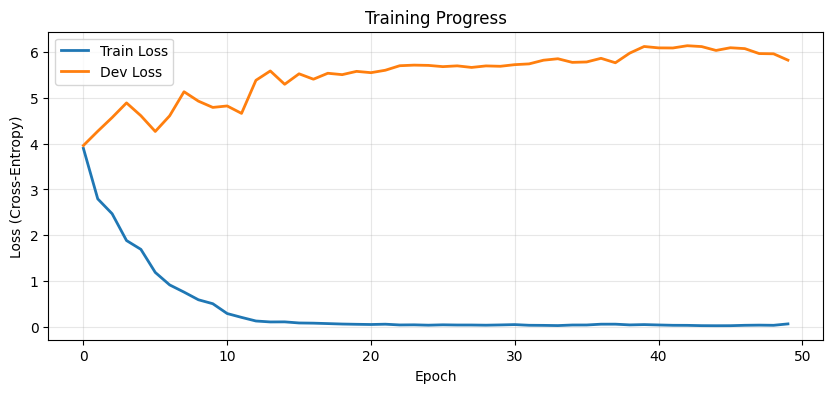


💡 Loss decreased! The model learned from the data!
   Cross-entropy loss is differentiable → we can compute gradients → we can train!


In [7]:
# Helper function to convert data to tensors
def prepare_data(data, src_vocab, tgt_vocab):
    """
    Convert word lists to tensors of IDs.
    
    Returns lists of source and target tensors.
    """
    src_tensors = []
    tgt_tensors = []
    
    for src_words, tgt_words in data:
        # Convert words to IDs
        src_ids = [src_vocab.word_to_id(w) for w in src_words]
        tgt_ids = [tgt_vocab.word_to_id(w) for w in tgt_words]
        
        # Convert to tensors
        src_tensors.append(torch.tensor(src_ids, dtype=torch.long))
        tgt_tensors.append(torch.tensor(tgt_ids, dtype=torch.long))
    
    return src_tensors, tgt_tensors

# Prepare training data
print("Preparing data...")
train_src, train_tgt = prepare_data(train_data, en_vocab, es_vocab)
dev_src, dev_tgt = prepare_data(dev_data, en_vocab, es_vocab)

print(f"✓ Prepared {len(train_src)} training examples")
print(f"✓ Prepared {len(dev_src)} dev examples")

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss(ignore_index=0)  # Ignore <PAD> tokens in loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"\n✓ Loss function: CrossEntropyLoss (ignore padding)")
print(f"✓ Optimizer: Adam (lr=0.001)")

print("\n" + "="*60)
print("TRAINING THE TRANSFORMER")
print("="*60)

# Training loop
num_epochs = 50
train_losses = []
dev_losses = []

for epoch in range(num_epochs):
    # Set model to training mode
    model.train()
    epoch_loss = 0
    
    # Train on each example
    for src, tgt in zip(train_src, train_tgt):
        # Move to device
        src = src.unsqueeze(0).to(device)  # (1, seq_len)
        tgt = tgt.unsqueeze(0).to(device)  # (1, seq_len)
        
        # Split target into input and output
        # Input: <SOS> w1 w2 w3 (what we feed to decoder)
        # Output: w1 w2 w3 <EOS> (what we're trying to predict)
        tgt_input = tgt[:, :-1]  # Remove last token
        tgt_output = tgt[:, 1:]   # Remove first token (<SOS>)
        
        # STEP 1: FORWARD PASS
        # Generate predictions for each position
        output = model(src, tgt_input)  # (1, seq_len-1, vocab_size)
        
        # STEP 2: COMPUTE LOSS
        # Compare predictions with ground truth
        # Reshape: (batch * seq_len, vocab_size) and (batch * seq_len)
        output = output.reshape(-1, output.size(-1))
        tgt_output = tgt_output.reshape(-1)
        loss = criterion(output, tgt_output)
        
        # STEP 3: BACKWARD PASS
        # Compute gradients
        optimizer.zero_grad()  # Clear old gradients
        loss.backward()  # Backpropagation!
        
        # STEP 4: UPDATE WEIGHTS
        # Use gradients to update parameters
        optimizer.step()
        
        epoch_loss += loss.item()
    
    # Average loss for this epoch
    avg_train_loss = epoch_loss / len(train_src)
    train_losses.append(avg_train_loss)
    
    # Evaluate on dev set (no gradient computation)
    model.eval()
    dev_loss = 0
    with torch.no_grad():
        for src, tgt in zip(dev_src, dev_tgt):
            src = src.unsqueeze(0).to(device)
            tgt = tgt.unsqueeze(0).to(device)
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]
            
            output = model(src, tgt_input)
            output = output.reshape(-1, output.size(-1))
            tgt_output = tgt_output.reshape(-1)
            loss = criterion(output, tgt_output)
            dev_loss += loss.item()
    
    avg_dev_loss = dev_loss / len(dev_src) if len(dev_src) > 0 else 0
    dev_losses.append(avg_dev_loss)
    
    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs}: Train Loss = {avg_train_loss:.4f}, Dev Loss = {avg_dev_loss:.4f}")

print("\n✓ Training complete!")
print(f"   Final train loss: {train_losses[-1]:.4f}")
print(f"   Final dev loss: {dev_losses[-1]:.4f}")

# Plot training progress
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(dev_losses, label='Dev Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (Cross-Entropy)')
plt.title('Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\n💡 Loss decreased! The model learned from the data!")
print("   Cross-entropy loss is differentiable → we can compute gradients → we can train!")


In [ ]:
# Test the trained model
print("Testing Trained Model")
print("="*60)

# Test on a few examples
test_examples = train_data[:5]  # Use some training examples to see if model learned

for en_words, es_words_ref in test_examples:
    # Convert to tensor
    en_ids = [en_vocab.word_to_id(w) for w in en_words]
    src_tensor = torch.tensor(en_ids, dtype=torch.long).unsqueeze(0).to(device)
    
    # Generate translation
    translated_ids = model.translate(src_tensor, max_length=20)
    
    # Convert IDs back to words
    translated_words = [es_vocab.id_to_word(idx) for idx in translated_ids]
    
    # Print results
    print(f"\nSource:     {' '.join(en_words)}")
    print(f"Reference:  {' '.join(es_words_ref)}")
    print(f"Prediction: {' '.join(translated_words)}")


Testing Trained Model

Source:     <SOS> no <EOS>
Reference:  <SOS> no <EOS>
Prediction: <SOS> no

Source:     <SOS> happy birthday <EOS>
Reference:  <SOS> feliz cumpleaños <EOS>
Prediction: <SOS> feliz cumpleaños

Source:     <SOS> nice to meet you <EOS>
Reference:  <SOS> mucho gusto <EOS>
Prediction: <SOS> mucho gusto

Source:     <SOS> how much <EOS>
Reference:  <SOS> cuánto cuesta <EOS>
Prediction: <SOS> cuánto cuesta

Source:     <SOS> help me <EOS>
Reference:  <SOS> ayúdame <EOS>
Prediction: <SOS> ayúdame

💡 The model learned to translate! (at least memorized training examples)
   With more data and training, it would generalize better.
